In [1]:
pip install -e ..

Obtaining file:///home/sagar/winogender_contextuality
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for winogender_contextuality (pyproject.toml) ... done
  Created wheel for winogender_contextuality: filename=winogender_contextuality-0.0.1-py3-none-any.whl size=4186 sha256=5eed96741c3cb245a121ac4b60105e0e0c7c7fdd356d536936aa34c6afbcdff1
  Stored in directory: /tmp/pip-ephem-wheel-cache-b324fr4h/wheels/f6/b9/38/03ac5a5ccd63b90faa34c1614fd3e708a9c34ab8edb44270e9
Successfully built winogender_contextuality
  Attempting uninstall: winogender_contextuality
    Found existing installation: winogender_contextuality 0.0.1
    Uninstalling winogender_contextuality-0.0.1:
      Successfully uninstalled winogender_contextuality-0.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict, Counter, OrderedDict
from tqdm.notebook import tqdm
from sklearn.feature_selection import mutual_info_regression
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.modeling.analysis import *
from winogender_contextuality.config import * 

2025-11-07 14:11:53.024 | INFO     | winogender_contextuality.config:<module>:13 - PROJ_ROOT path is: /home/sagar/winogender_contextuality
2025-11-07 14:11:53.025 | INFO     | winogender_contextuality.config:<module>:17 - DATA_ROOT path is: /data_users1/sagar/winogender_contextuality


# Constants

In [3]:
max_idx = 180

In [4]:
case_index = {
    "$NOM_PRONOUN": 0,
    "$POSS_PRONOUN": 1,
    "$ACC_PRONOUN": 2
}

In [5]:
case_pronouns = {
    "$NOM_PRONOUN": ['he', 'she'],
    "$POSS_PRONOUN": ['his', 'her'],
    "$ACC_PRONOUN": ['him', 'her']
}

# Functions

In [44]:
def primed_completion_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60,
                                  CIs: bool = False,
                                  plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []
    ci_list = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        # Lists
        unprimed_1 = get_sent_order([0, 1], get_single_sentences(all_index_data))
        unprimed_2 = get_sent_order([1, 0], get_single_sentences(all_index_data))

        primed_m1 = get_sent_order([0, 1], get_filled_pnoun(0, all_index_data))
        primed_f1 = get_sent_order([0, 1], get_filled_pnoun(1, all_index_data))
        primed_m2 = get_sent_order([1, 0], get_filled_pnoun(0, all_index_data))
        primed_f2 = get_sent_order([1, 0], get_filled_pnoun(1, all_index_data))


        # Probabilities
        p_unprimed_1 = prob_func(unprimed_1)
        p_unprimed_2 = prob_func(unprimed_2)

        p_primed_m1 = prob_func(primed_m1)
        p_primed_f1 = prob_func(primed_f1)
        p_primed_m2 = prob_func(primed_m2)
        p_primed_f2 = prob_func(primed_f2)

        tup1 = (p_unprimed_1, p_primed_m1, p_primed_f1)
        tup2 = (p_unprimed_2, p_primed_m2, p_primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

        if CIs:
            if mode == 'internal':
                raise ValueError("No CIs around internal logits.")
                
            ci_unprimed_1 = get_generation_cis(unprimed_1)
            ci_unprimed_2 = get_generation_cis(unprimed_2)
    
            ci_primed_m1 = get_generation_cis(primed_m1)
            ci_primed_f1 = get_generation_cis(primed_f1)
            ci_primed_m2 = get_generation_cis(primed_m2)
            ci_primed_f2 = get_generation_cis(primed_f2)
    
            ci_tup1 = (ci_unprimed_1, ci_primed_m1, ci_primed_f1)
            ci_tup2 = (ci_unprimed_2, ci_primed_m2, ci_primed_f2)
    
            try: 
                ci_list.append(ci_tup1)
                ci_list.append(ci_tup2)
            except ValueError:
                print(ci_tup1, ci_tup2)
            

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    if CIs:
        return differences, ci_list
    else:
        return differences

In [7]:
def create_feature_table(index: int, 
                         data: list[Measurement] | list[dict],
                         features_df: pd.DataFrame):

    """
    Creates a DataFrame with columns [Measurement, Role, GPrime, POrder] for a *pair of sentences* using measurements provided. 

    ONLY OUTPUTS PRIMED INSTANCES.

    :param ratio: whether to exclude instances where target role has no ratio.

    :param data: List of Measurements (or equivalent dictionaries) 

    """

    fwd_list = get_sent_order([0,1],get_index(index,data, filter_none=True))
    bwd_list = get_sent_order([1,0],get_index(index,data, filter_none=True))

    forward_index = 2 * index
    reverse_index = 2 * index + 1

    forward_occ = features_df["role"][forward_index]
    reverse_occ = features_df["role"][reverse_index]

    forward_role = features_df["role_type"][forward_index]
    reverse_role = features_df["role_type"][reverse_index]

    forward_case = case_index[features_df["pronoun_type"][forward_index]]
    reverse_case = case_index[features_df["pronoun_type"][reverse_index]]

    forward_stereo = features_df["stereotype"][forward_index]
    reverse_stereo = features_df["stereotype"][reverse_index]

    fwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in fwd_list]
    bwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in bwd_list]

    fwd_measurement_list = [m['measurement']['BLANK'] for m in fwd_list if m['measurement']['BLANK'] is not None]
    bwd_measurement_list = [m['measurement']['BLANK'] for m in bwd_list if m['measurement']['BLANK'] is not None]

    fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in fwd_list]
    bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in bwd_list]

    measurements_df = pd.DataFrame(data={
        'Measurement': fwd_measurement_list + bwd_measurement_list, 
        'Role': [forward_occ] * len(fwd_list) + [reverse_occ]*len(bwd_list),
        'Role_Type': [forward_role] * len(fwd_list) + [reverse_role]*len(bwd_list),
        'Case': [forward_case] * len(fwd_list) + [reverse_case]*len(bwd_list),
        'Stereotype': [forward_stereo] * len(fwd_list) + [reverse_stereo]*len(bwd_list),
        'Prime': fwd_prime_list + bwd_prime_list,
        'Order': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
    })

    measurements_df["X"] = (measurements_df["Measurement"] == "she").astype(int)
    measurements_df["y_role_type"] = (measurements_df["Role_Type"] == "occupation").astype(int)
    measurements_df["y_prime"] = (measurements_df["Prime"] == "she").astype(int)
    measurements_df["y_stereo"] = measurements_df["Stereotype"]
    measurements_df["y_order"] = (measurements_df["Order"]).astype(int)
    measurements_df["y_primed"] = [i != 'None' for i in measurements_df["Prime"]]

    return measurements_df
    
    

In [8]:
def get_contextuality_table(
        model_measurements: list[dict],
        default_pronoun: int = 1,  # 0 for male, 1 for female
        max_index: int = 60
) -> pd.DataFrame:
    indices = []

    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []

    for idx in tqdm(range(max_index)):

        try:

            # Internal
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')

            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')

            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')



        except Exception as e:
            logger.error(f"Error calculating degree of contextuality for index {idx}: {e}")
            continue

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df


# Loading Data

## Raw WinoPron Templates

In [9]:
raw_templates = pd.read_csv(RAW_DATA_DIR/"new_templates.tsv", sep="\t")

## Stereotypes Dataset

In [10]:
stereo = pd.read_csv(RAW_DATA_DIR/"occupation_english_means_final.csv")

## WinoPron T=0.5

In [11]:
gpt_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5_wp.json")
max_gpt = max([x["index"] for x in gpt_wp])
f"{len(gpt_wp)} Measuremenents"

'289600 Measuremenents'

In [12]:
phi_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_phi-4_0.5_wp.ndjson")
max_phi = max([x["index"] for x in phi_wp])
f"{len(phi_wp)} Measuremenents"

'256676 Measuremenents'

In [13]:
mistral_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Mistral-7B-Instruct-v0.2_0.5_wp.ndjson")
max_mistral = max([x["index"] for x in mistral_wp])
f"{len(mistral_wp)} Measuremenents"

'214575 Measuremenents'

In [14]:
llama1b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1512241025.ndjson")
max_llama1b = max([x["index"] for x in llama1b_wp])
f"{len(llama1b_wp)} Measuremenents"

'1158400 Measuremenents'

In [15]:
llama8b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.1-8B-Instruct_0.5_wp.ndjson")
max_llama8b = max([x["index"] for x in llama8b_wp])
f"{len(llama8b_wp)} Measuremenents"

'289600 Measuremenents'

In [16]:
qwen_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen2.5-7B-Instruct_0.5_wp.ndjson")
max_qwen = max([x["index"] for x in qwen_wp])
f"{len(qwen_wp)} Measuremenents"

'220087 Measuremenents'

In [17]:
deep_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_DeepSeek-R1-Distill-Qwen-7B_0.5_wp.ndjson")
max_deep = max([x["index"] for x in deep_wp])
f"{len(deep_wp)} Measuremenents"

'192547 Measuremenents'

In [18]:
#deep_wp
#mistral_wp
winopron_results_05 = [gpt_wp, phi_wp, llama1b_wp, llama8b_wp, qwen_wp]

In [19]:
#'mistral'
#'deepseek'
model_names = ['gpt', 'phi',  'llama1b', 'llama8b', 'qwen']

## WinoPron Null

## Creating a list of all sentences

In [20]:
winopron_pairs = pd.read_csv(INTERIM_DATA_DIR/"winopron_pairs.tsv", sep="\t")
winopron_pairs.head()

,template_1,differences_1,case_1,referent_1,template_2,differences_2,case_2,referent_2
0,The technician told the customer that BLANK co...,"['he', 'she']",$NOM_PRONOUN,customer,The technician told the customer that BLANK ha...,"['he', 'she']",$NOM_PRONOUN,technician
1,The technician had to call the customer for BL...,"['him', 'her']",$ACC_PRONOUN,customer,The technician had to call the customer for BL...,"['him', 'her']",$ACC_PRONOUN,technician
2,The customer told the technician that BLANK fr...,"['his', 'her']",$POSS_PRONOUN,customer,The customer told the technician that BLANK ch...,"['his', 'her']",$POSS_PRONOUN,technician
3,The taxpayer met with the accountant to find o...,"['he', 'she']",$NOM_PRONOUN,taxpayer,The taxpayer met with the accountant to find o...,"['he', 'she']",$NOM_PRONOUN,accountant
4,The taxpayer met with the accountant for BLANK...,"['him', 'her']",$ACC_PRONOUN,taxpayer,The taxpayer met with the accountant for BLANK...,"['him', 'her']",$ACC_PRONOUN,accountant


In [130]:
all_sentences_wp = pd.DataFrame()
all_templates = []
all_pnouns = []
all_referents = []
all_cases = []
for idx in winopron_pairs.index:
    for n in [1,2]:
        all_templates.append(winopron_pairs[f"template_{n}"][idx])
        all_pnouns.append(winopron_pairs[f"differences_{n}"][idx])
        all_referents.append(winopron_pairs[f"referent_{n}"][idx])
        all_cases.append(winopron_pairs[f"case_{n}"][idx])

all_sentences_wp['template'] = all_templates
all_sentences_wp['differences'] = all_pnouns
all_sentences_wp['referent'] = all_referents
all_sentences_wp['case'] = all_cases

In [131]:
all_sentences_wp.head()

,template,differences,referent,case
0,The technician told the customer that BLANK co...,"['he', 'she']",customer,$NOM_PRONOUN
1,The technician told the customer that BLANK ha...,"['he', 'she']",technician,$NOM_PRONOUN
2,The technician had to call the customer for BL...,"['him', 'her']",customer,$ACC_PRONOUN
3,The technician had to call the customer for BL...,"['him', 'her']",technician,$ACC_PRONOUN
4,The customer told the technician that BLANK fr...,"['his', 'her']",customer,$POSS_PRONOUN


In [132]:
#all_sentences_wp.to_csv(INTERIM_DATA_DIR/"all_sentences_wp.csv")

## Calculating Average Null

# Generation Differences

In [24]:
priming_labels = ['Unprimed', 'Male Primed', 'Female Primed']

In [46]:
all_gen_diffs = [primed_completion_differences(d, 
                                               mode='generation',
                                               max_index = max([x["index"] for x in d]),
                                               CIs = True
                                              )
                 for d in winopron_results_05]

 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                        | 154/180 [00:43<00:06,  3.74it/s]

2025-11-07 14:21:25.578 | DEBUG    | winogender_contextuality.utils:get_generation_probs:256 - Likely no measurements found. Exception raised: list index out of range
2025-11-07 14:21:25.581 | DEBUG    | winogender_contextuality.utils:get_generation_probs:256 - Likely no measurements found. Exception raised: list index out of range
2025-11-07 14:21:25.585 | DEBUG    | winogender_contextuality.utils:get_generation_cis:286 - Likely no measurements found. Exception raised: list index out of range
2025-11-07 14:21:25.588 | DEBUG    | winogender_contextuality.utils:get_generation_cis:286 - Likely no measurements found. Exception raised: list index out of range


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:09<00:00, 19.01it/s]


## Individual Items

<ErrorbarContainer object of 3 artists>

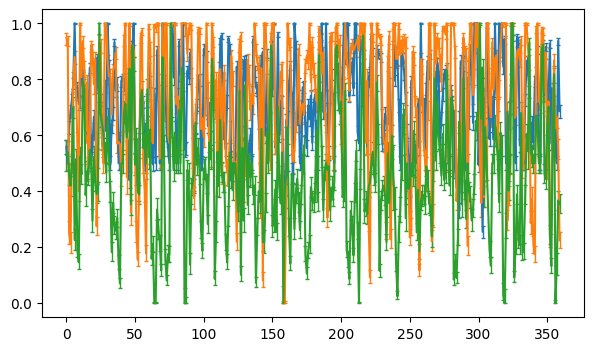

In [129]:
def clip_errs(lower, upper, min_val=0.0):
    lower = np.maximum(lower, min_val)
    upper = np.maximum(upper, min_val)
    return np.vstack([lower, upper])

test_model_results = all_gen_diffs[2] # 0 - GPT

plt.figure(figsize=(7, 4))

# Unprimed
unprimed_ps = np.array([i[0][1] for i in test_model_results[0]])
unprimed_cis = np.array([i[0][1] for i in test_model_results[1]])

lower_err = unprimed_ps - unprimed_cis[:, 0]
upper_err = unprimed_cis[:, 1] - unprimed_ps
yerr = clip_errs(lower_err, upper_err, 1e-12)

plt.errorbar(range(len(test_model_results[0])), unprimed_ps, yerr=yerr,
            elinewidth=1, capsize=1.5)

# Male Primed
mprimed_ps = np.array([i[1][1] for i in test_model_results[0]])
mprimed_cis = np.array([i[1][1] for i in test_model_results[1]])

lower_err_m = mprimed_ps - mprimed_cis[:, 0]
upper_err_m = mprimed_cis[:, 1] - mprimed_ps
yerr_m = clip_errs(lower_err_m, upper_err_m, 1e-12)

plt.errorbar(range(len(test_model_results[0])), mprimed_ps, yerr=yerr_m,
            elinewidth=1, capsize=1.5)

# Female Primed
findices = []
fprimed_ps = []
fprimed_cis = []
for i in range(len(test_model_results[0])):
    try: 
        fprimed_ps.append(test_model_results[0][i][2][1])
        fprimed_cis.append(test_model_results[1][i][2][1])
        findices.append(i)
    except TypeError:
        pass

findices = np.array(findices)
fprimed_ps = np.array(fprimed_ps)
fprimed_cis = np.array(fprimed_cis)


lower_err_f = fprimed_ps - fprimed_cis[:, 0]
upper_err_f = fprimed_cis[:, 1] - fprimed_ps
yerr_f = clip_errs(lower_err_f, upper_err_f, 1e-12)
plt.errorbar(findices, fprimed_ps, yerr=yerr_f,
            elinewidth=1, capsize=1.5)

## $\chi^2$

In [115]:
from scipy.stats import chi2_contingency

In [106]:
# DELETE WHEN RERUNNING
def get_generation_details(measurements: list[Measurement] | list[dict]) -> np.ndarray:
    """
    Returns successes and total number of measurements from each trial.

    :param measurements: list of Measurement objects (or equivelant dictionaries)
    :return: array of probabilities
    """
    # pronoun set is determined by the first measurement
    try:
        pnouns = measurements[0]['context']['pronouns_2']
    except Exception as e:
        logger.debug(f"Likely no measurements found. Exception raised: {e}")
        return np.nan

    # calculate empirical generation probabilities (remove anything not in the list of pronouns)
    generated_pnouns = []
    for m in measurements:
        try:
            generated_pnouns.append(m['measurement']['BLANK'])
        except Exception as e:
            logger.debug(f"Exception {e} raised for item {m}")
            pass
    generation_counter = Counter(generated_pnouns)
    generation_counter_clean = {k: generation_counter[k] for k in pnouns}
    num_valid_measurements = np.sum(list(generation_counter_clean.values()))
    return generation_counter_clean, num_valid_measurements

In [111]:
test_d, test_ct = get_generation_details(get_sent_order([0, 1], get_single_sentences(get_index(0, gpt_wp))))
test_dm, test_ctm = get_generation_details(get_sent_order([0, 1], get_filled_pnoun(0, get_index(0, gpt_wp))))
test_df, test_ctf = get_generation_details(get_sent_order([0, 1], get_filled_pnoun(1, get_index(0, gpt_wp))))

In [113]:
test_d

{'he': 273, 'she': 127}

In [118]:
test_table = np.array([
    [test_d['she'], test_dm['she'], test_df['she']],                 # successes
    [test_d['he'], test_dm['he'], test_df['he']]                     # failures
])

In [119]:
chi2, p, dof, expected = chi2_contingency(test_table)
chi2, p, dof, expected 

(np.float64(266.53125),
 np.float64(1.3288453319051866e-58),
 2,
 array([[160.,  80.,  80.],
        [240., 120., 120.]]))

## Average Across All Instances

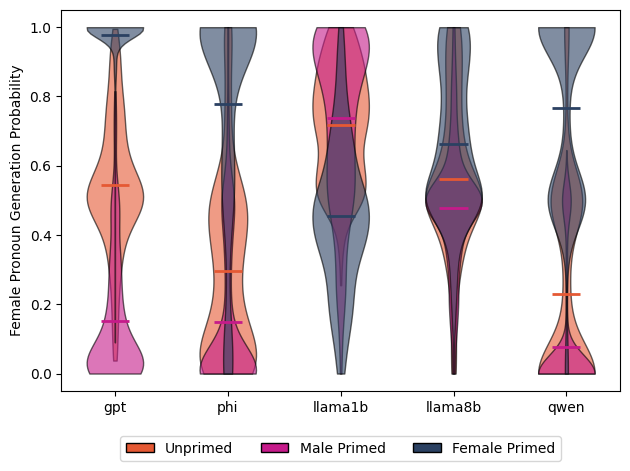

In [27]:
all_generation_probabilities = []
for n in range(3):
    all_priming_probs = []
    for model,_ in all_gen_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except TypeError:
                pass
        all_priming_probs.append(fem_probs)
    all_generation_probabilities.append(all_priming_probs)


vp_colors = ['#E55934', '#C51B8A', '#2B4162']

for n in range(3):
    parts = plt.violinplot(all_generation_probabilities[n], 
                           showmeans=True, 
                           showextrema=False)
    for i, vp in enumerate(parts['bodies']):
        vp.set_facecolor(vp_colors[n])
        vp.set_edgecolor('black')
        vp.set_alpha(0.6)
    if 'cmeans' in parts and parts['cmeans'] is not None:
        parts['cmeans'].set_color(vp_colors[n])     # one color per violin
        parts['cmeans'].set_linewidth(2)
        parts['cmeans'].set_alpha(1)
        
plt.xticks(range(1, len(model_names)+1), model_names)

handles = [Patch(facecolor=vp_colors[i], edgecolor='black', label=priming_labels[i]) for i in range(len(vp_colors))]
plt.legend(handles=handles, 
           loc='upper center',          # place legend at top center of the box
           bbox_to_anchor=(0.5, -0.1),  # move it below the axes
           ncol=len(handles))  
plt.ylabel("Female Pronoun Generation Probability")
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"violin_plots_0.5_5models.pdf")

# Internal Differences

## Average Across All Instances

 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                         | 153/180 [00:43<00:06,  4.17it/s]/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 180/180 [00:09<00:00, 19.47it/s]


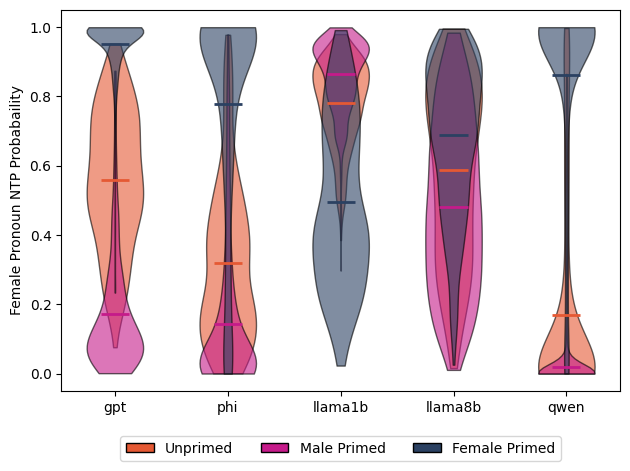

In [28]:
all_int_diffs = [primed_completion_differences(d, mode='internal',
                                              max_index = max([x["index"] for x in d])
                                              )
                 for d in winopron_results_05]

all_internal_probabilities = []
for n in range(3):
    all_priming_probs = []
    for model in all_int_diffs:
        fem_probs = []
        for x in model:
            try:
                fem_probs.append(x[n][1])
            except IndexError:
                pass
        all_priming_probs.append(fem_probs)
    all_internal_probabilities.append(all_priming_probs)

vp_colors = ['#E55934', '#C51B8A', '#2B4162']

for n in range(3):
    parts = plt.violinplot(all_internal_probabilities[n], 
                           showmeans=True, 
                           showextrema=False)
    for i, vp in enumerate(parts['bodies']):
        vp.set_facecolor(vp_colors[n])
        vp.set_edgecolor('black')
        vp.set_alpha(0.6)
    if 'cmeans' in parts and parts['cmeans'] is not None:
        parts['cmeans'].set_color(vp_colors[n])     # one color per violin
        parts['cmeans'].set_linewidth(2)
        parts['cmeans'].set_alpha(1)
        
plt.xticks(range(1, len(model_names)+1), model_names)

handles = [Patch(facecolor=vp_colors[i], edgecolor='black', label=priming_labels[i]) for i in range(len(vp_colors))]
plt.legend(handles=handles, 
           loc='upper center',          # place legend at top center of the box
           bbox_to_anchor=(0.5, -0.1),  # move it below the axes
           ncol=len(handles))  
plt.ylabel("Female Pronoun NTP Probabaility")
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"violin_plots_0.5_5models.pdf")

# Correlations with Cultural Biases

## Data Prep

In [29]:
raw_templates.head()

,occupation(0),other-participant(1),answer,pronoun_type,template,single_version
0,technician,customer,1,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $PARTICIPANT was told that $NOM_PRONOUN co...
1,technician,customer,0,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...,The $OCCUPATION said that $NOM_PRONOUN had com...
2,technician,customer,1,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $PARTICIPANT received a call for $ACC_PRON...
3,technician,customer,0,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...,The $OCCUPATION called for $ACC_PRONOUN to con...
4,technician,customer,1,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...,The $PARTICIPANT said that $POSS_PRONOUN fridg...


In [30]:
# Setting occupation as index
stereo.set_index('occupation', inplace=True, drop=True)

In [31]:
all_roles = set(raw_templates["occupation(0)"]).union(set(raw_templates["other-participant(1)"]))

In [32]:
# Now, taking the data from raw_templates and creating a DF with the index, missing role, pronoun type, stereotype, occupational or not
roles = []
role_types = []
for idx in raw_templates.index:
    answer = raw_templates["answer"][idx]
    if answer == 0:
        role = raw_templates["occupation(0)"][idx]
        role_type = "occupation"
    else:
        role = raw_templates["other-participant(1)"][idx]
        role_type = "participant"
        
    roles.append(role)
    role_types.append(role_type)
    

all_features = pd.DataFrame(data={"role": roles, "role_type": role_types})
all_features["stereotype"] = [stereo["english_mean"][role] for role in roles]
all_features["pronoun_type"] = raw_templates["pronoun_type"]
all_features["template"] = raw_templates["template"]
all_features.head()

,role,role_type,stereotype,pronoun_type,template
0,customer,participant,0.58,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...
1,technician,occupation,0.35,$NOM_PRONOUN,The $OCCUPATION told the $PARTICIPANT that $NO...
2,customer,participant,0.58,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...
3,technician,occupation,0.35,$ACC_PRONOUN,The $OCCUPATION had to call the $PARTICIPANT f...
4,customer,participant,0.58,$POSS_PRONOUN,The $PARTICIPANT told the $OCCUPATION that $PO...


In [33]:
all_features_wstereo = all_features[~np.isnan(all_features["stereotype"])]

In [34]:
print(f"Collected gender stereotypes for {len(all_features_wstereo)} out of {len(all_features)} sentences.")

Collected gender stereotypes for 279 out of 360 sentences.


## Testing Correlations

In [35]:
# now do this for all models and for all primings
# also do if for internal logits
# Ideally, we see significant correlations only in the unprimed case, but these vanish in primed cases

### Generation

#### Unprimed

In [36]:
unprimed_spearmans = []
unprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_gen_diffs[n]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans.append(corr)
    unprimed_pvals.append(p)

#### Male Primed

In [37]:
mprimed_spearmans = []
mprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[1][1] for x in all_gen_diffs[n]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    mprimed_spearmans.append(corr)
    mprimed_pvals.append(p)

#### Female Primed

In [38]:
fprimed_spearmans = []
fprimed_pvals = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_gen_diffs[n]):
        try:
            fem_probs.append(x[2][1])
            fem_idxs.append(i)
        except TypeError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    fprimed_spearmans.append(corr)
    fprimed_pvals.append(p)

#### Plotting 

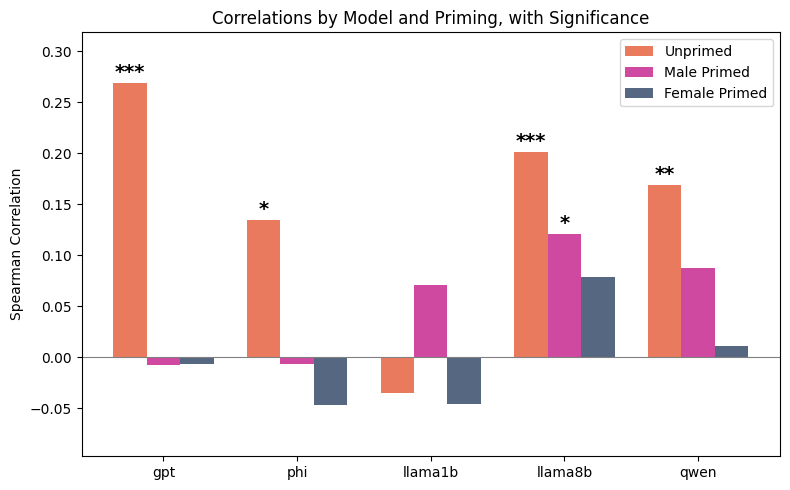

In [39]:
# --- Plot setup ---
corr_colors = {
    'unprimed': '#E55934',   
    'mprimed':  '#C51B8A',
    'fprimed':  '#2B4162'   
}

x = np.arange(len(winopron_results_05))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width, unprimed_spearmans, width, label='Unprimed', color=corr_colors['unprimed'], alpha=0.8)
bars2 = ax.bar(x, mprimed_spearmans, width, label='Male Primed', color=corr_colors['mprimed'], alpha=0.8)
bars3 = ax.bar(x + width, fprimed_spearmans, width, label='Female Primed', color=corr_colors['fprimed'], alpha=0.8)

# --- Add significance asterisks ---
def annotate_significance(bars, pvals):
    for bar, p in zip(bars, pvals):
        height = bar.get_height()
        if p < 0.001:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '***',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '**',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )
        elif p < 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.001, '*',
                ha='center', va='bottom',
                fontsize=14, fontweight='bold', color='black'
            )

min_height = min([min(unprimed_spearmans), min(mprimed_spearmans), min(fprimed_spearmans)])
max_height = max([max(unprimed_spearmans), max(mprimed_spearmans), max(fprimed_spearmans)])
            

annotate_significance(bars1, unprimed_pvals)
annotate_significance(bars2, mprimed_pvals)
annotate_significance(bars3, fprimed_pvals)

# --- Formatting ---
ax.set_ylabel('Spearman Correlation')
ax.set_title('Correlations by Model and Priming, with Significance')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=0)
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylim(min_height - 0.05, max_height + 0.05)

# Tidy layout
plt.tight_layout()
#plt.savefig(REPORTS_DIR/"figures"/"spearman_correlations_0.5_models.pdf")
plt.show()

### Interal

In [40]:
unprimed_spearmans_int = []
unprimed_pvals_int = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[0][1] for x in all_int_diffs[n]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    unprimed_spearmans_int.append(corr)
    unprimed_pvals_int.append(p)

In [41]:
mprimed_spearmans_int = []
mprimed_pvals_int = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    corr_df["stereotype"] = all_features["stereotype"]
    corr_df["fem_prob"] = [x[1][1] for x in all_int_diffs[n]]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    mprimed_spearmans_int.append(corr)
    mprimed_pvals_int.append(p)

In [42]:
fprimed_spearman_int = []
fprimed_pvals_int = []

for n,model in enumerate(winopron_results_05):
    corr_df = pd.DataFrame()
    fem_probs = []
    fem_idxs = []
    for i,x in enumerate(all_int_diffs[n]):
        try:
            fem_probs.append(x[2][1])
            fem_idxs.append(i)
        except IndexError:
            pass
    corr_df["fem_prob"] = fem_probs
    corr_df["stereotype"] = all_features["stereotype"][fem_idxs]
    corr_df_valid = corr_df[~np.isnan(corr_df["stereotype"])]
    corr, p = spearmanr(corr_df_valid["stereotype"], corr_df_valid["fem_prob"])
    fprimed_spearman_int.append(corr)
    fprimed_pvals_int.append(p)

In [43]:
unprimed_pvals_int, mprimed_pvals_int, fprimed_pvals_int

([np.float64(2.8966423714592757e-08),
  np.float64(0.003843767582985412),
  np.float64(0.24280722447667374),
  np.float64(2.45278990128781e-06),
  np.float64(0.0005610130764378726)],
 [np.float64(0.6914048210980204),
  np.float64(0.6769943427065447),
  np.float64(0.7448978238641928),
  np.float64(0.0015784307804413637),
  np.float64(0.46931370079425994)],
 [np.float64(0.13683645123178798),
  np.float64(0.30193905431082635),
  np.float64(0.32407485692102944),
  np.float64(0.28366087373433424),
  np.float64(0.7071829425951464)])


# Mutual Information